In [47]:
import sklearn
from sklearn.datasets import load_diabetes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [25]:
df = pd.read_csv(r"discarded_cropORdist.csv")
df["amp"] = df["max"] - df["min"]

In [26]:
df["lc2022"].value_counts()

lc2022
4     2021
9      506
10     236
11      94
5       37
6       33
1       11
Name: count, dtype: int64

In [27]:
df_high_peaks = df[df["total_peaks"] > 15]

In [28]:
df_high_peaks["lc2022"].value_counts()

lc2022
4     1409
10     206
9      170
11      80
6        6
1        1
Name: count, dtype: int64

In [55]:
lc_summary = {
    "lc":[],
    "mean": [],
    "min": [],
    "max": [],
    "amp": []
}

for lc in [4, 10, 9, 11, 6, 1]:
    lc_df = df_high_peaks[df_high_peaks["lc2022"] == lc]

    z = np.abs(stats.zscore(lc_df["min"], nan_policy="omit"))
    no_outliers_df = lc_df[z <= 2]
    print(f"Outliers found: {(z > 2).sum()}")

    mean = no_outliers_df["mean"].mean()
    min = no_outliers_df["min"].mean()
    max = no_outliers_df["max"].mean()
    amp = no_outliers_df["amp"].mean()

    lc_summary["lc"].append(lc)
    lc_summary["mean"].append(mean)
    lc_summary["min"].append(min)
    lc_summary["max"].append(max)
    lc_summary["amp"].append(amp)

summary_df = pd.DataFrame(lc_summary)


Outliers found: 54
Outliers found: 12
Outliers found: 5
Outliers found: 4
Outliers found: 0
Outliers found: 0


In [56]:
summary_df

,lc,mean,min,max,amp
0,4,0.644287,0.271718,0.906884,0.635166
1,10,0.487082,0.143768,0.836773,0.693005
2,9,0.323655,0.074682,0.667812,0.593130
3,11,0.597284,0.240405,0.874637,0.634232
4,6,0.349917,0.130433,0.674033,0.543600
5,1,NaN,NaN,NaN,NaN


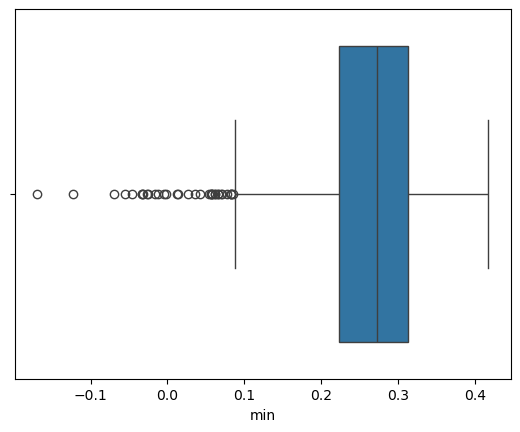

In [44]:
sns.boxplot(x=df_high_peaks[df_high_peaks["lc2022"] == 4]["min"])
plt.show()